# Medium-sized Inversions
Here, we visualize the inversions that were identified for the `medium` treatment across the range of depths. The `LEVIATHAN` small, medium, and large call rates are configured to `-s 95 -m 95 -l 90`.

In [13]:
library(ggplot2)
library(dplyr)
options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)
.size <- "medium"

These are the setup functions that process that data.

In [14]:
read_data <- function(size_treatment, depth){
    .depth <- paste("depth",depth, sep = "_")
    truthfile <- paste0("simulated_variants/inversions_genomes/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_sample90/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_pop90/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"

    sample_inversions <- read.table(samplesfile, header = T)[,1:4]

    pooled_inversions <- read.table(poolfile, header = T)
    pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
    names(pooled_inversions)[1] <- "sample"
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- "pooled" #paste("pooled", depth, size_treatment, sep = "_")
    }
    return(rbind(true_inversions, sample_inversions, pooled_inversions))
}

assess_performace <- function(data, out_df){
    truth <- filter(data, sample == "simulated_inversions")
    truth <- group_by(truth, contig) %>% mutate(id = 1:n())
    samples <- filter(data, sample != "simulated_inversions")
    for(i in 1:nrow(samples)){
        .row <- samples[i,]
        contig <- .row$contig
        .sample <- .row$sample
        startpos <- .row$position_start
        endpos <- .row$position_end
        tb <- filter(truth, contig == contig, (position_start - 500 <= startpos) & (position_end + 500 >= endpos))
        if(nrow(tb) > 0){
            out_df[out_df$sample == .sample & out_df$contig == contig & out_df$inversion == tb$id, "state"] <- "true positive"
        }
    }
    out_df$contig <- gsub("2L", "2L (all homozygous)", out_df$contig)
    out_df$contig <- gsub("2R", "2R (all heterozygous)", out_df$contig)
    out_df$contig <- gsub("3L", "3L (inversions common)", out_df$contig)
    out_df$contig <- gsub("3R", "3R (inversions rare)", out_df$contig)
    return(out_df)
}

In [15]:
plot_data <- function(data, size_treatment, depth){
    axis_ticks <- factor(c("pooled", paste0("sample_", sprintf("%02d", 1:10)), "simulated_inversions"))
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_discrete(limits = axis_ticks) +
        labs(title = "Called Inversions", subtitle = paste0("Size: ", size_treatment, " | Depth: ", depth,"X"), x = "genomic position (bp)", caption = "simulated_inversions are groundtruth") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

plot_matrix <- function(data, size_treatment, depth){
    axis_ticks <- factor(c("pooled", paste0("sample_", sprintf("%02d", 1:10))))
    ggplot(data, aes(y = sample, x = inversion, fill = state)) +
        geom_tile(color = "white") +
        theme_light() +
        labs(title = "Was an inversion detected?", subtitle = paste0("Size: ", size_treatment, " | Depth: ", depth,"X")) +
        scale_fill_manual(values = c("#ffecb8", "grey70", "#90aed8")) +
        scale_x_continuous(1:5,name = "Inversion ID") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_wrap(vars(contig), nrow = 1)
}

A function to wrap all these other functions for simplicity.

In [16]:
summarize_performance <- function(depth, inventory, .size){
    .data <- read_data(.size, depth)
    .performance <- assess_performace(.data, inventory)
    show(plot_matrix(.performance, .size, depth))
    show(plot_data(.data, .size, depth))
    return(.performance)
}

Read in the sample and pool simulation inventory

In [17]:
inventory <- rbind(
    filter(read.table("inversion_simulations.inventory", header = T), size == .size),
    filter(read.table("inversion_simulations.pool.inventory", header = T), size == .size)
)
performance <- rename(inventory, "simulated" = "present", "zygosity" = "state")
# set a default to false negatives, to be updated to true positives when conditions are met
performance$state <- "false negative"
# there are no false positives, so we can default inversions that weren't simulated to true negatives
performance[!performance$simulated, 7] <- "true negative"
# fix the name of pool to pooled
performance$sample <- gsub("pool", "pooled", performance$sample)
# read in truth data to transfer inversion breakpoints
x <- read_data(.size, 5)
truth <- group_by(x[x$sample == "simulated_inversions",], contig) %>% mutate(inversion = 1:n())
truth <- truth[, c(1,5,2,3)]
performance <- merge(performance,truth, by = c("contig", "inversion"))
performance <- performance[, c(1,2,8,9,3:7)]
head(performance)

,contig,inversion,position_start,position_end,sample,size,simulated,zygosity,state
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<chr>
1,2L,1,1591146,1776073,sample_01,medium,TRUE,hom,false negative
2,2L,1,1591146,1776073,sample_03,medium,TRUE,hom,false negative
3,2L,1,1591146,1776073,sample_10,medium,TRUE,hom,false negative
4,2L,1,1591146,1776073,sample_05,medium,TRUE,hom,false negative
5,2L,1,1591146,1776073,sample_02,medium,TRUE,hom,false negative
6,2L,1,1591146,1776073,pooled,medium,TRUE,hom,false negative


## 0.5X depth

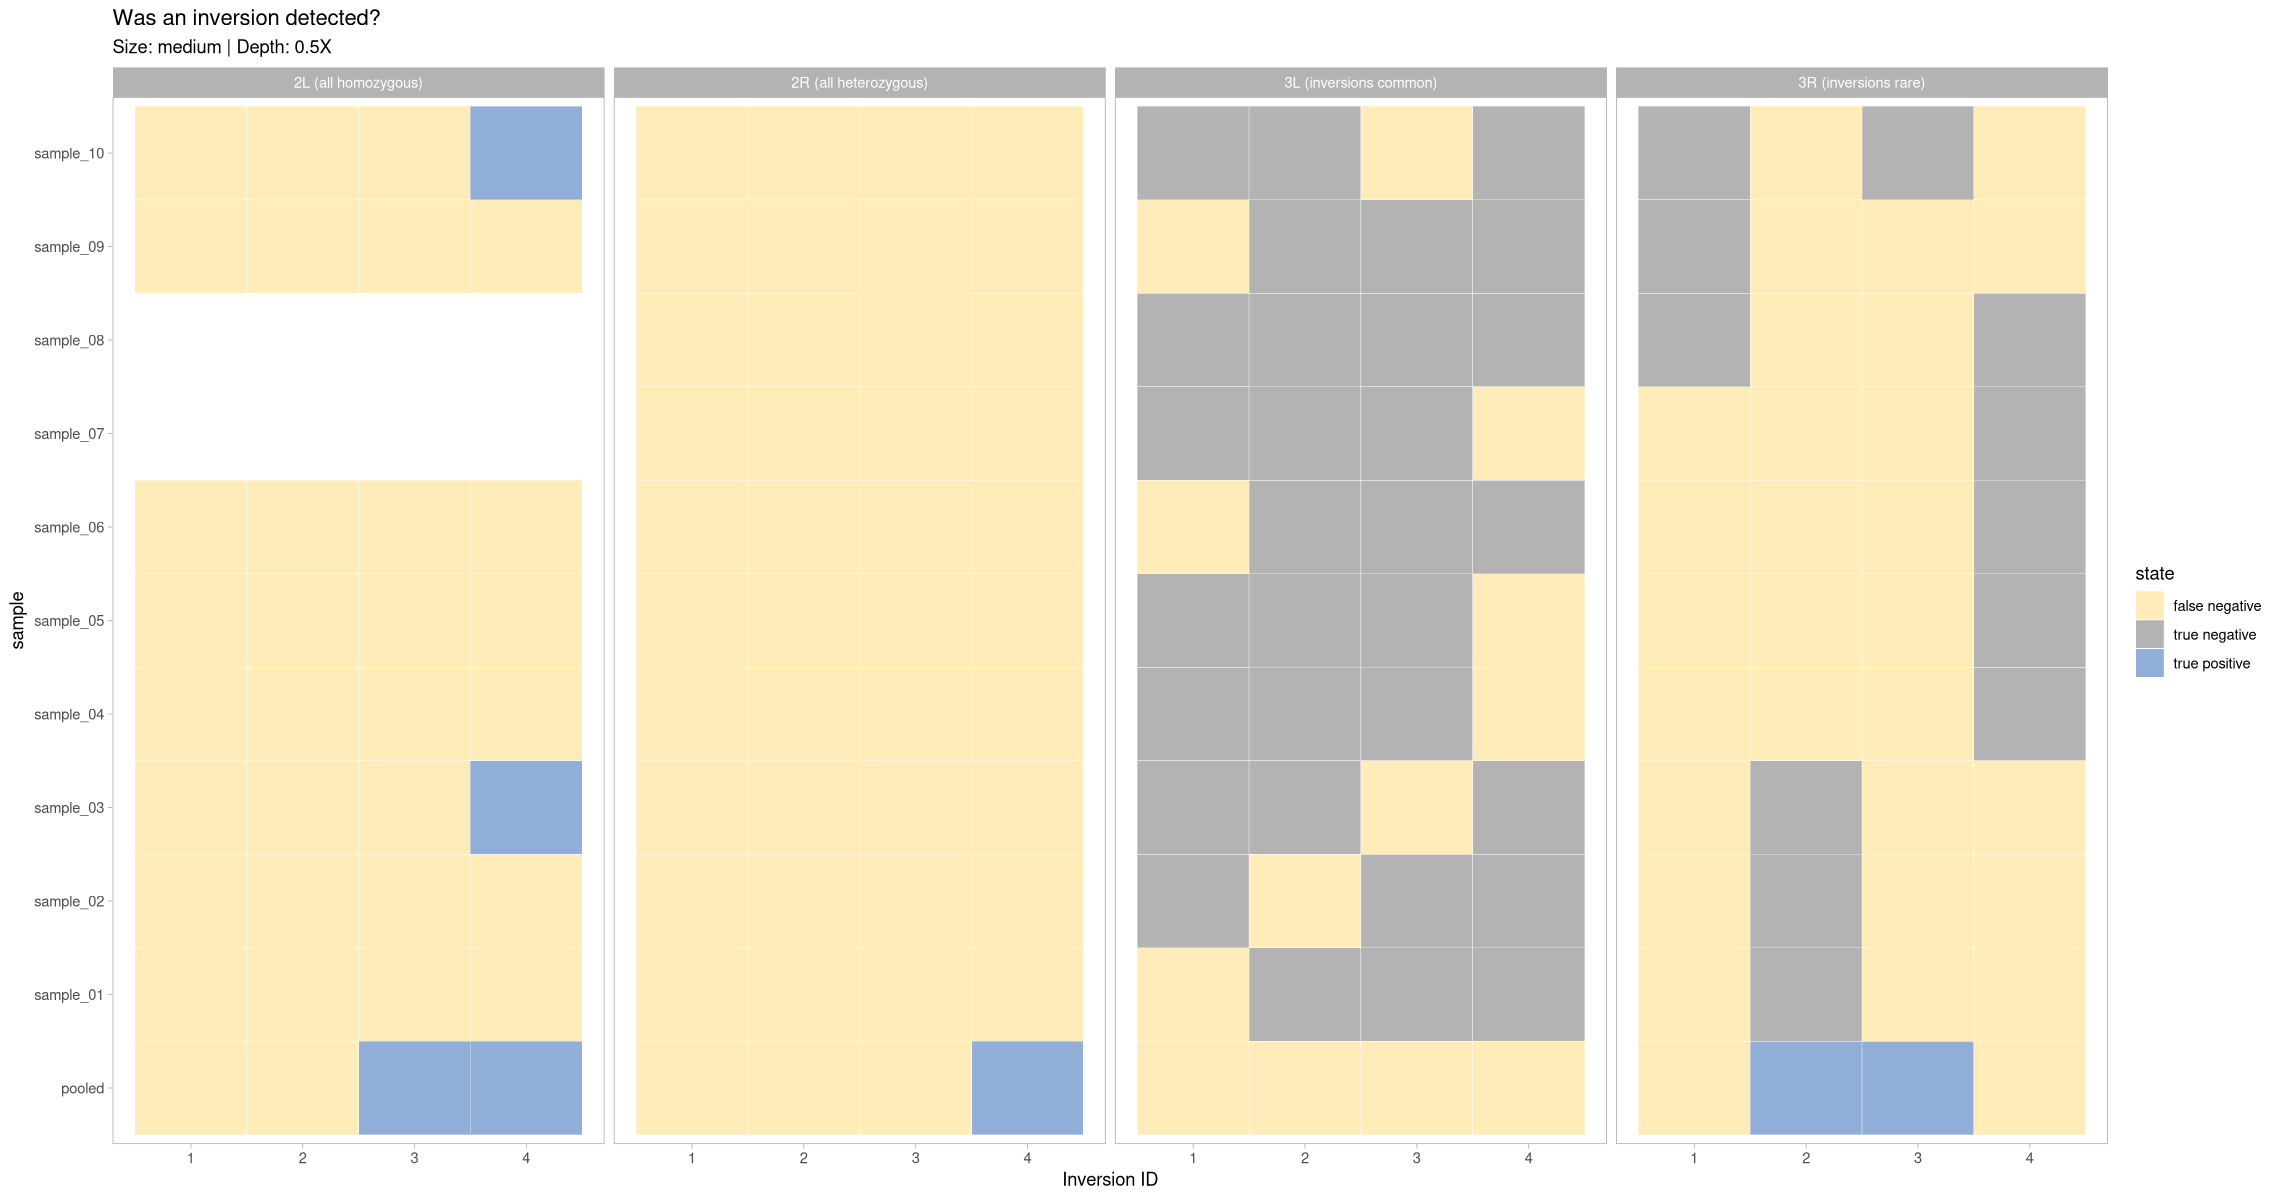

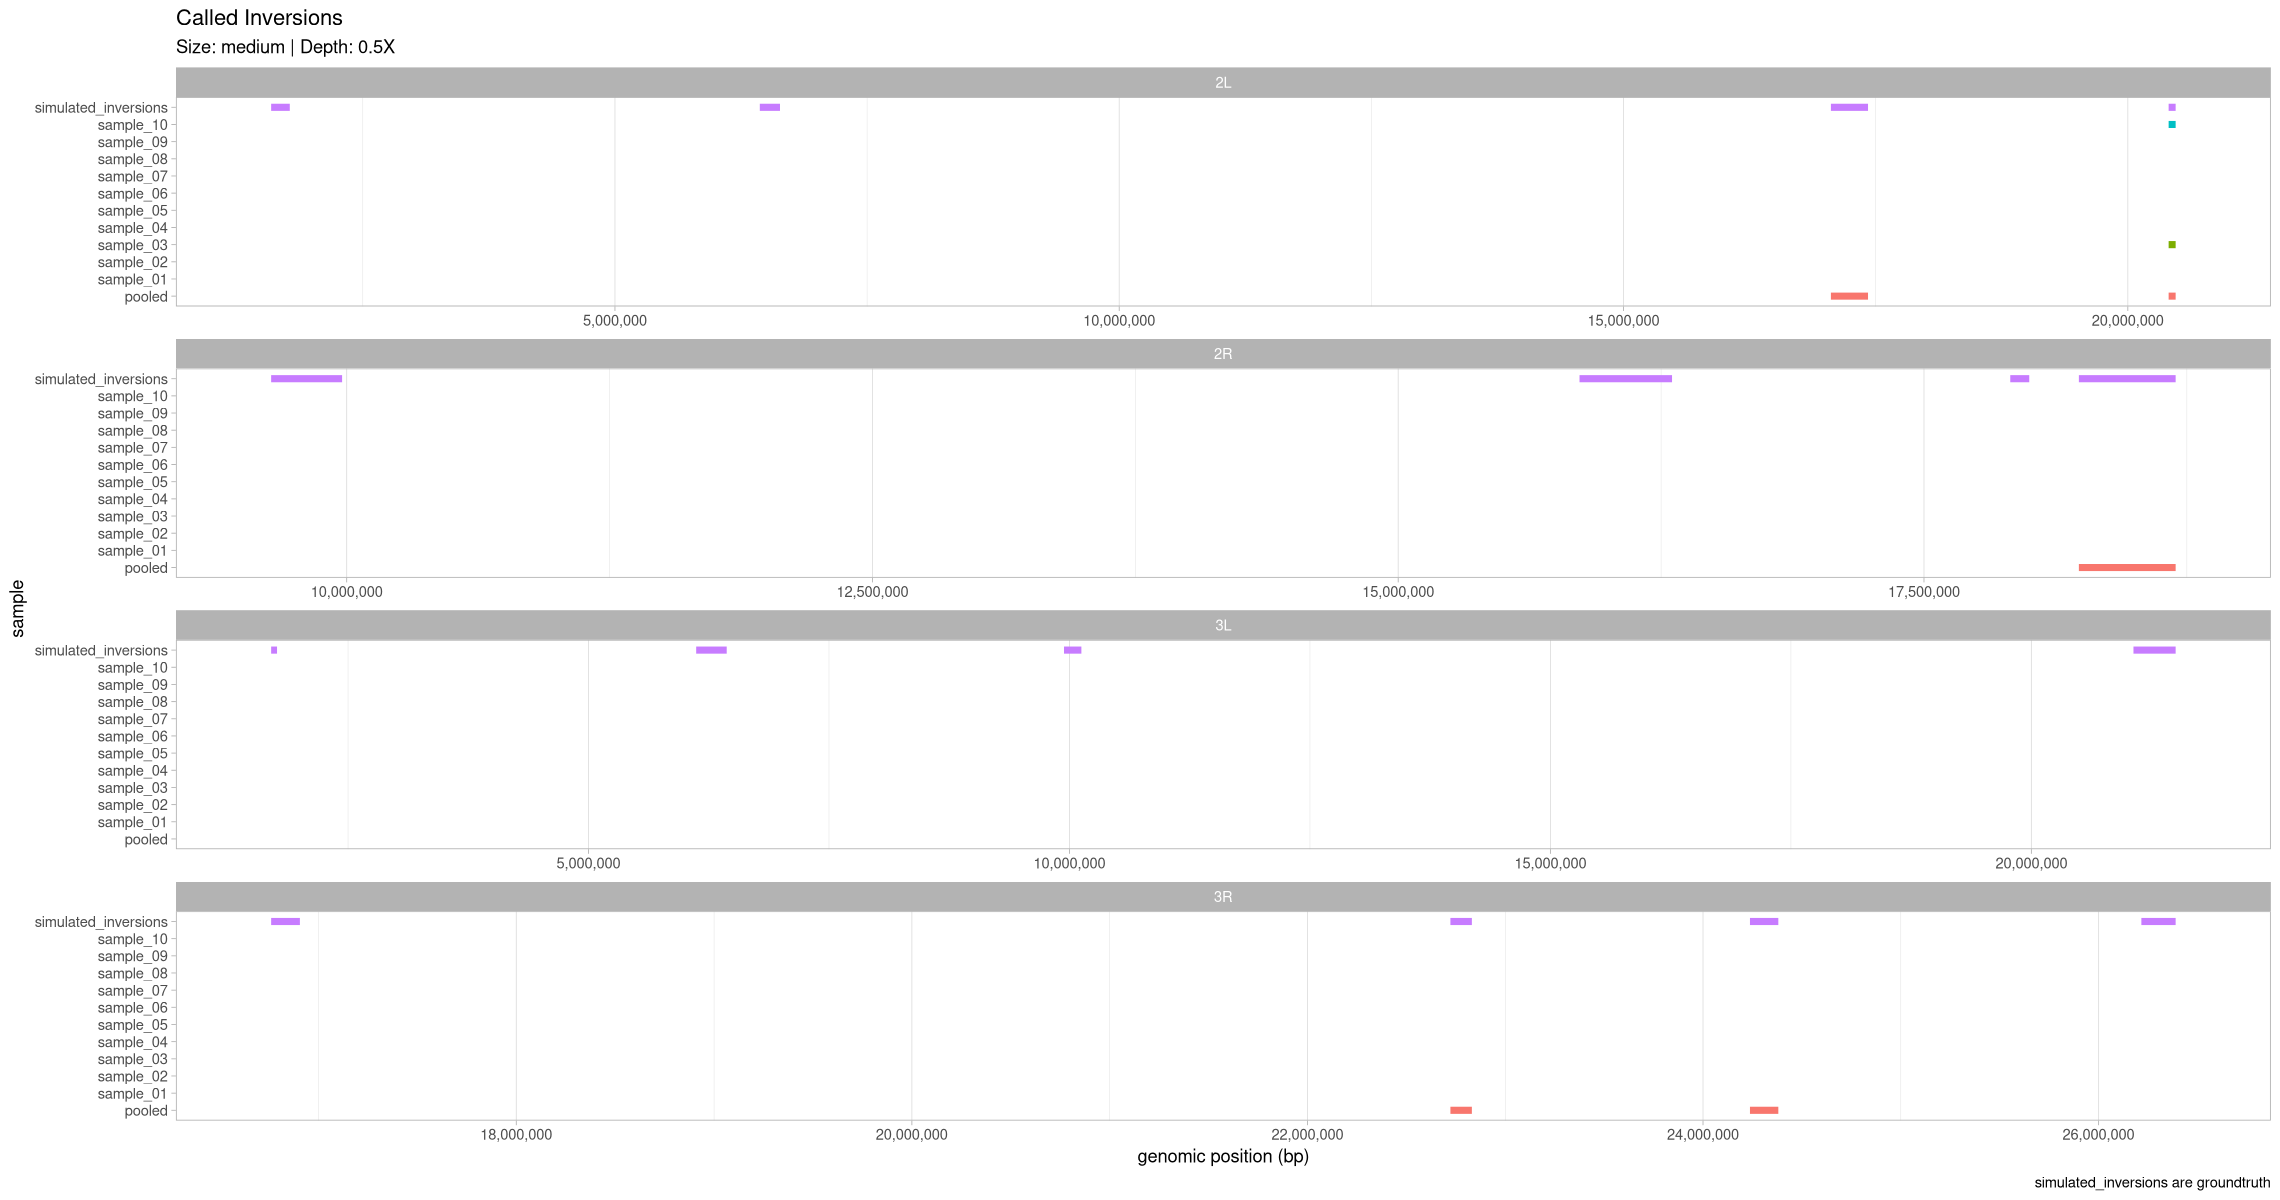

In [18]:
assessment_05X <- summarize_performance(0.5, performance, .size)

## 2X Depth

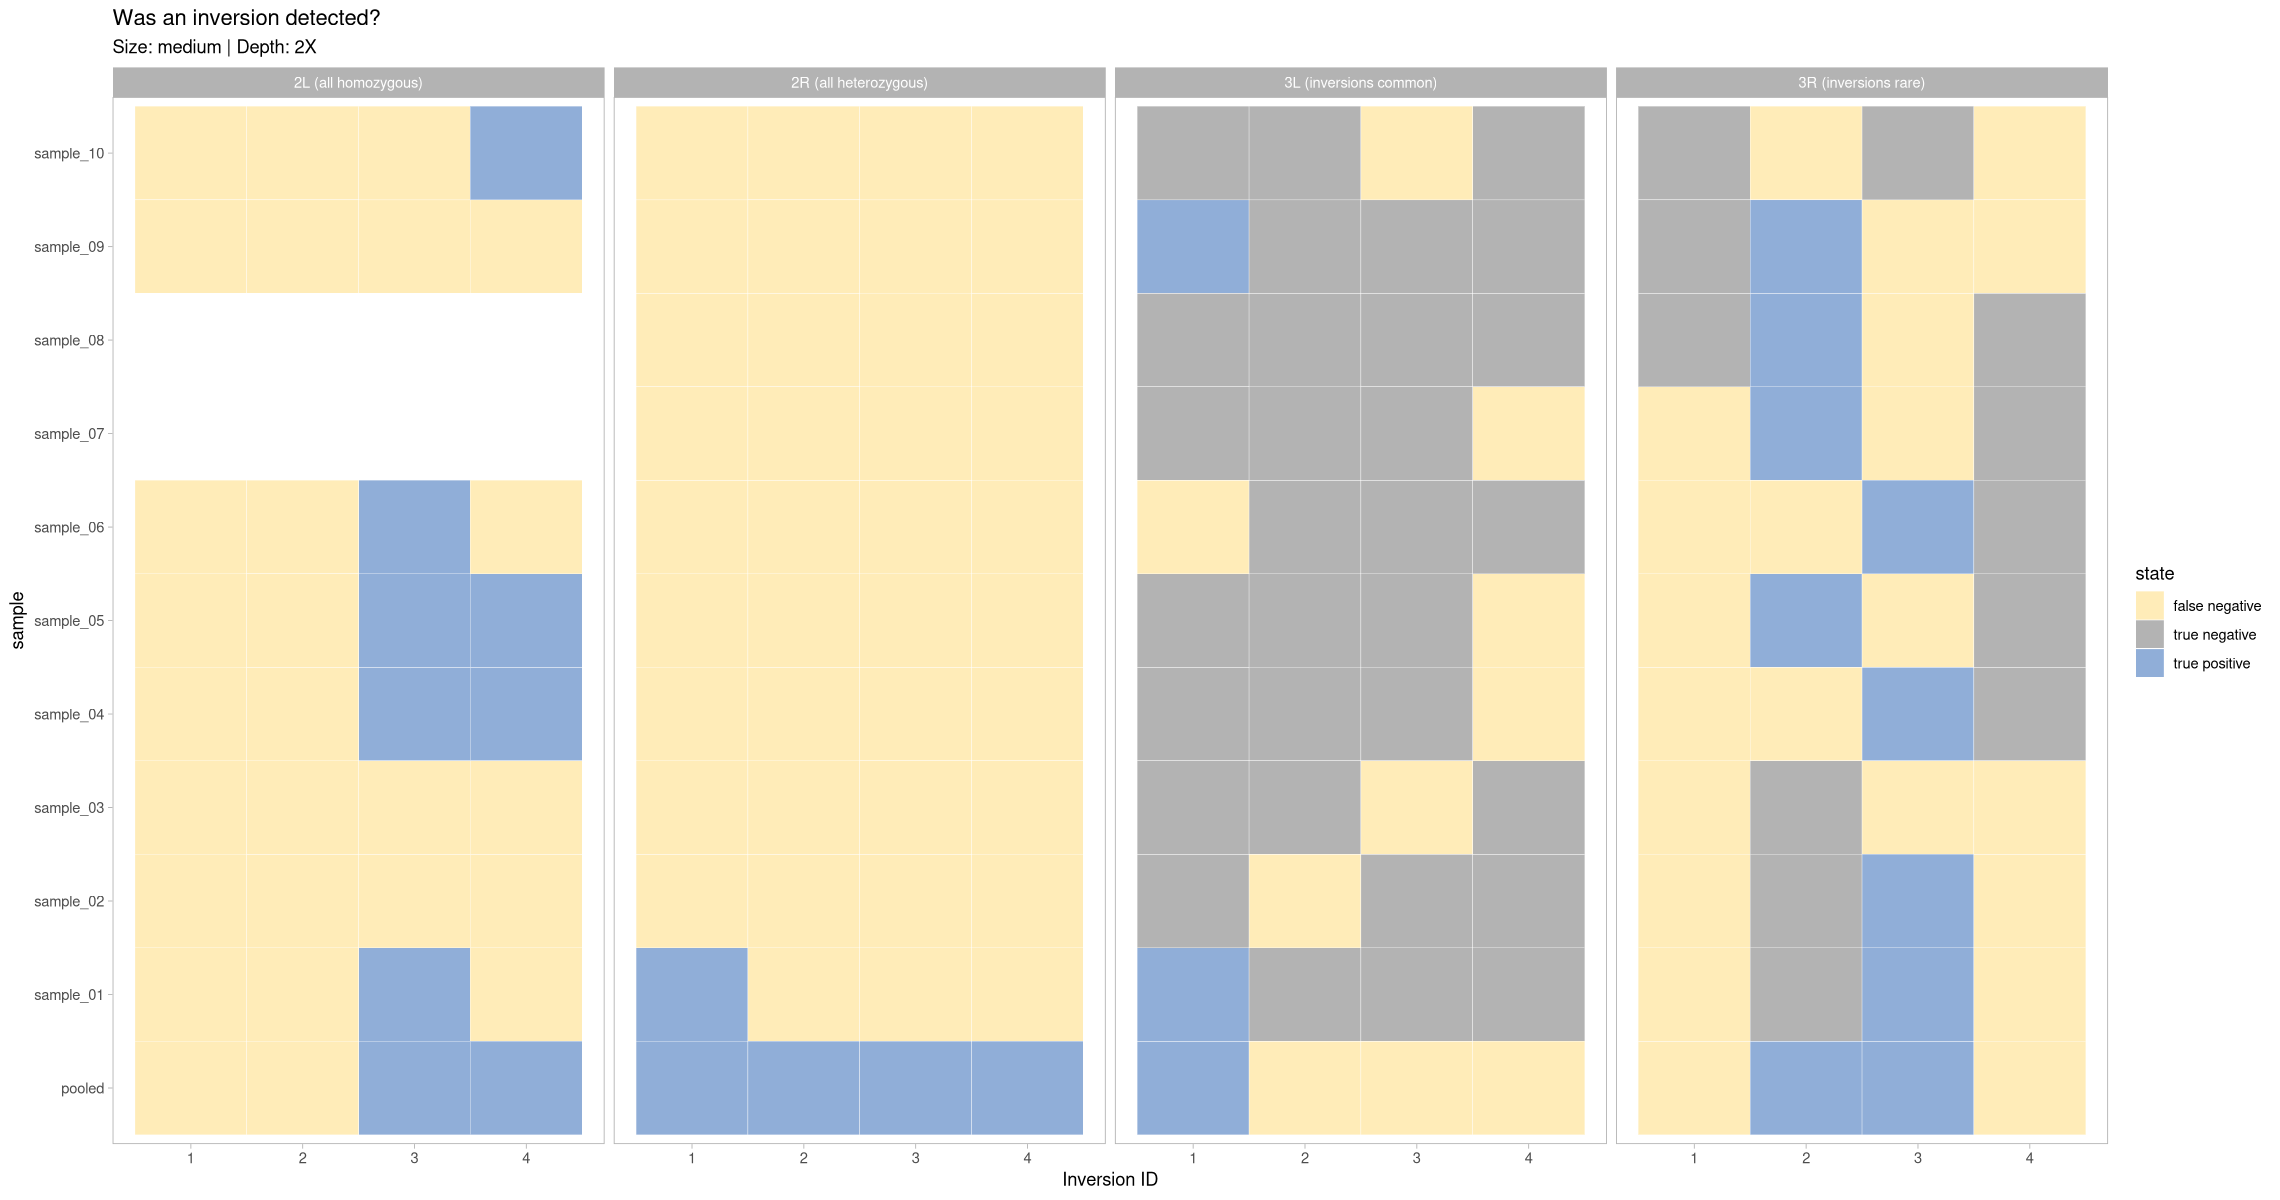

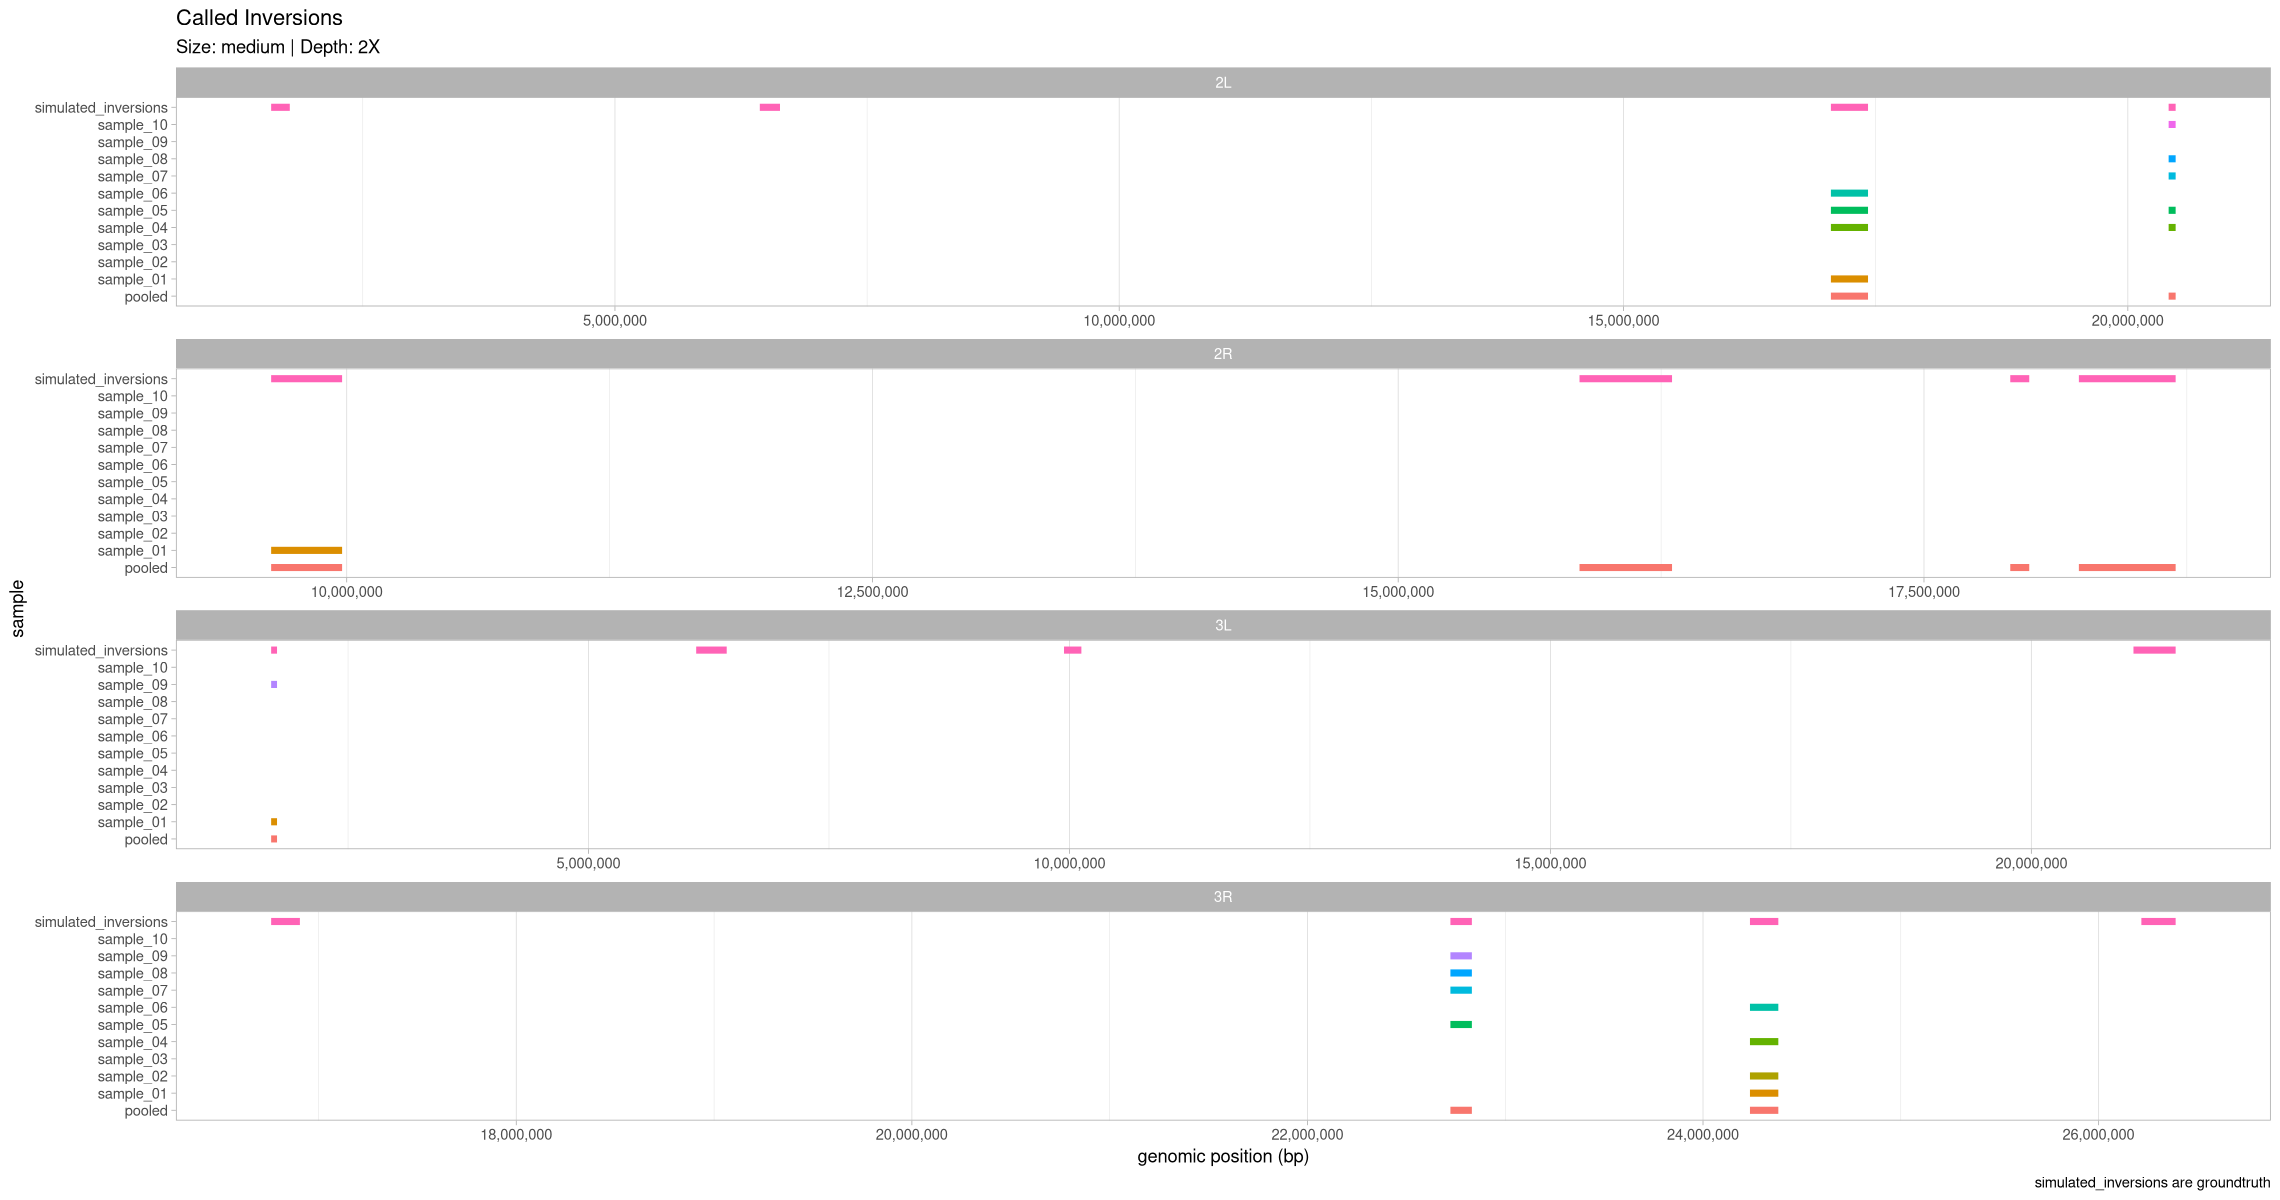

In [19]:
assessment_2X <- summarize_performance(2, performance, .size)

## 5X Depth

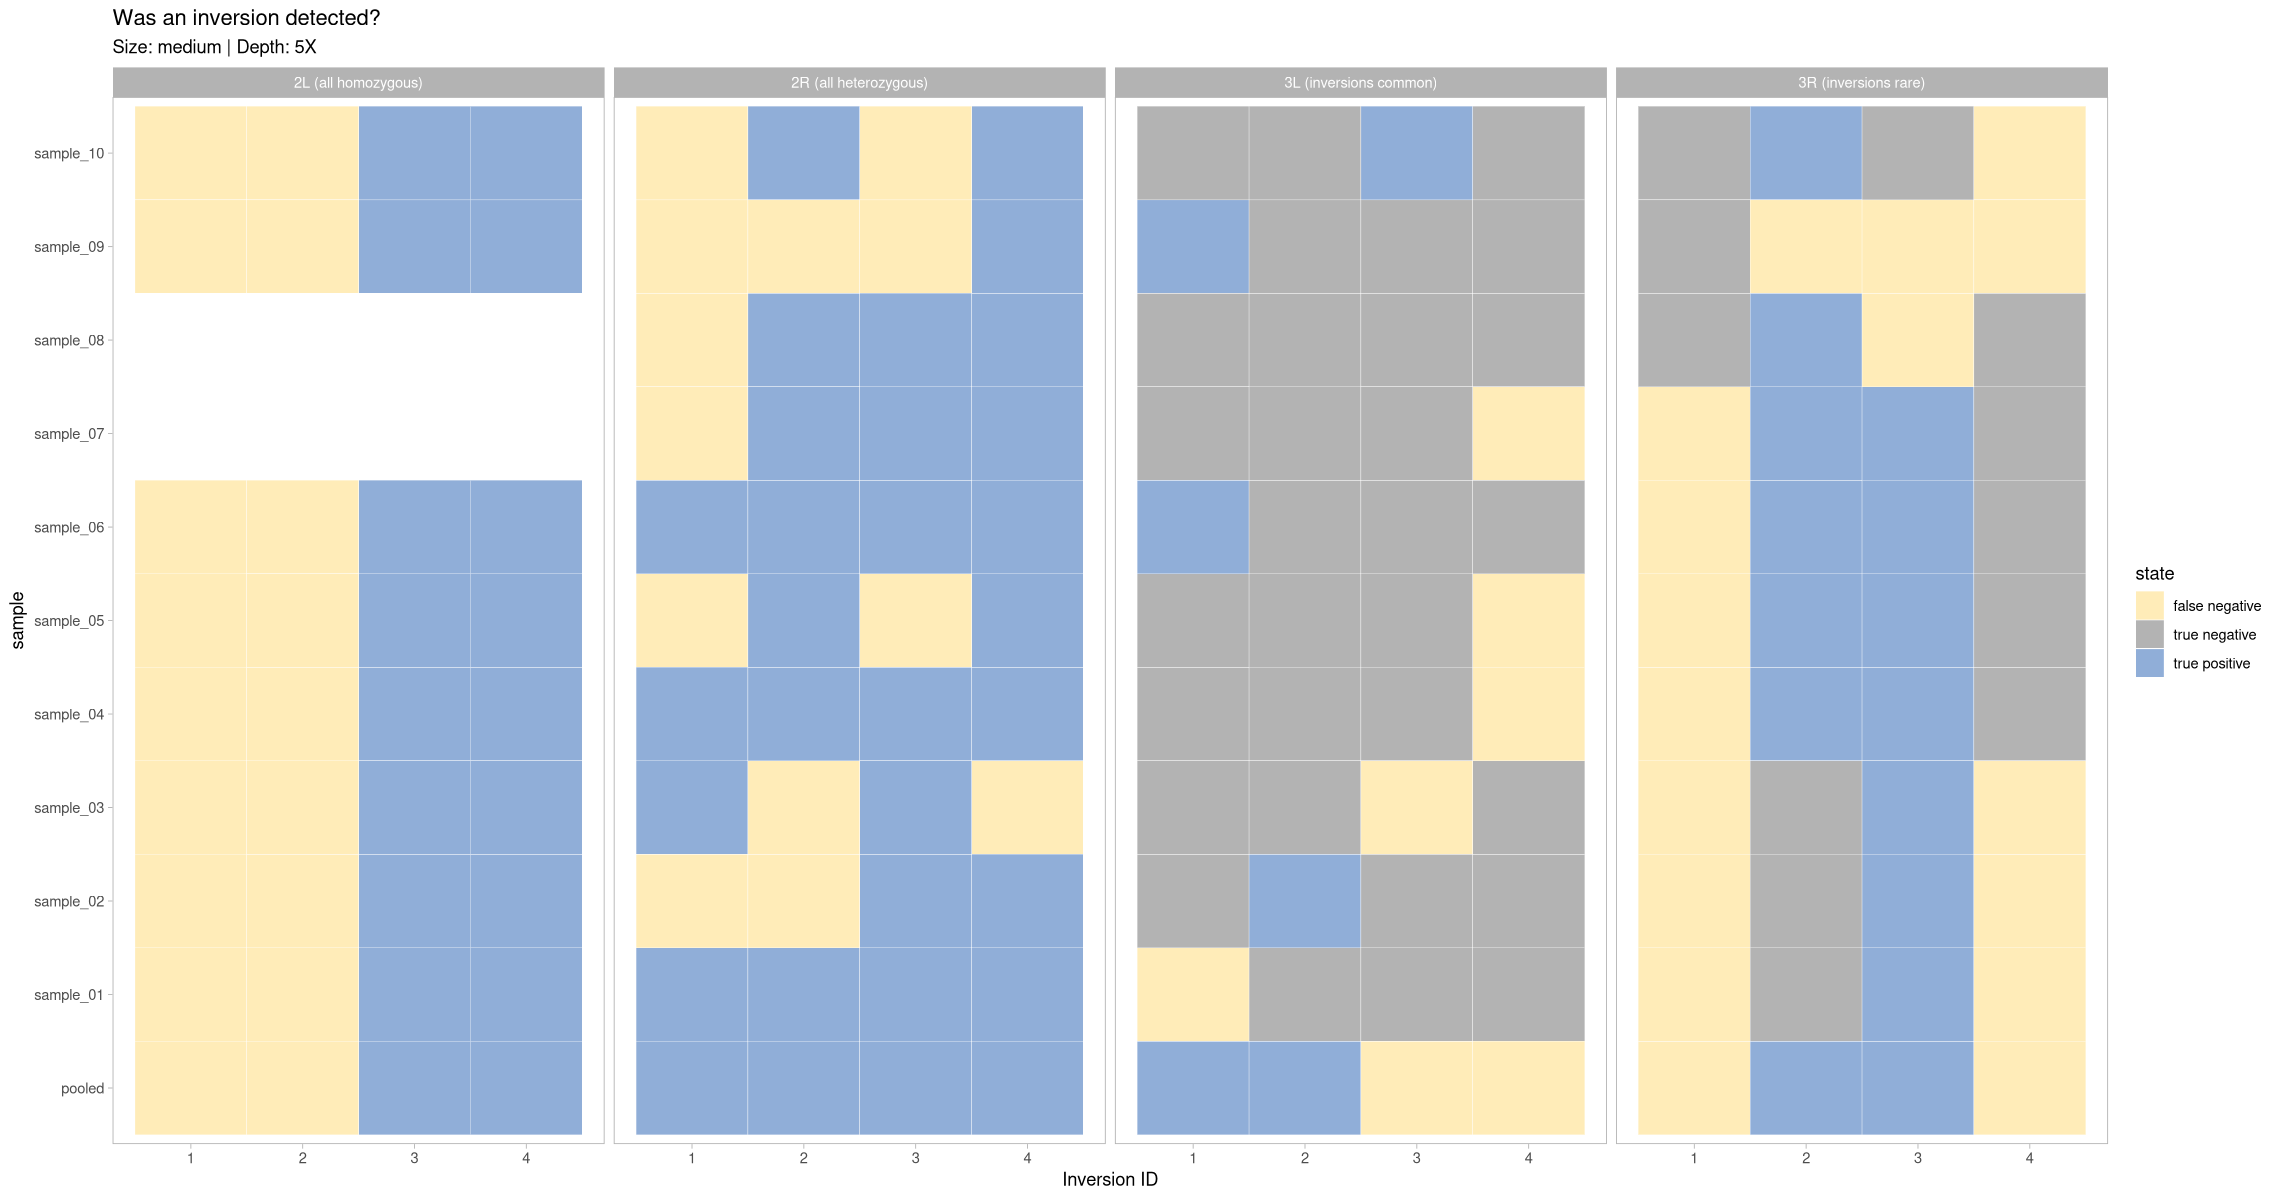

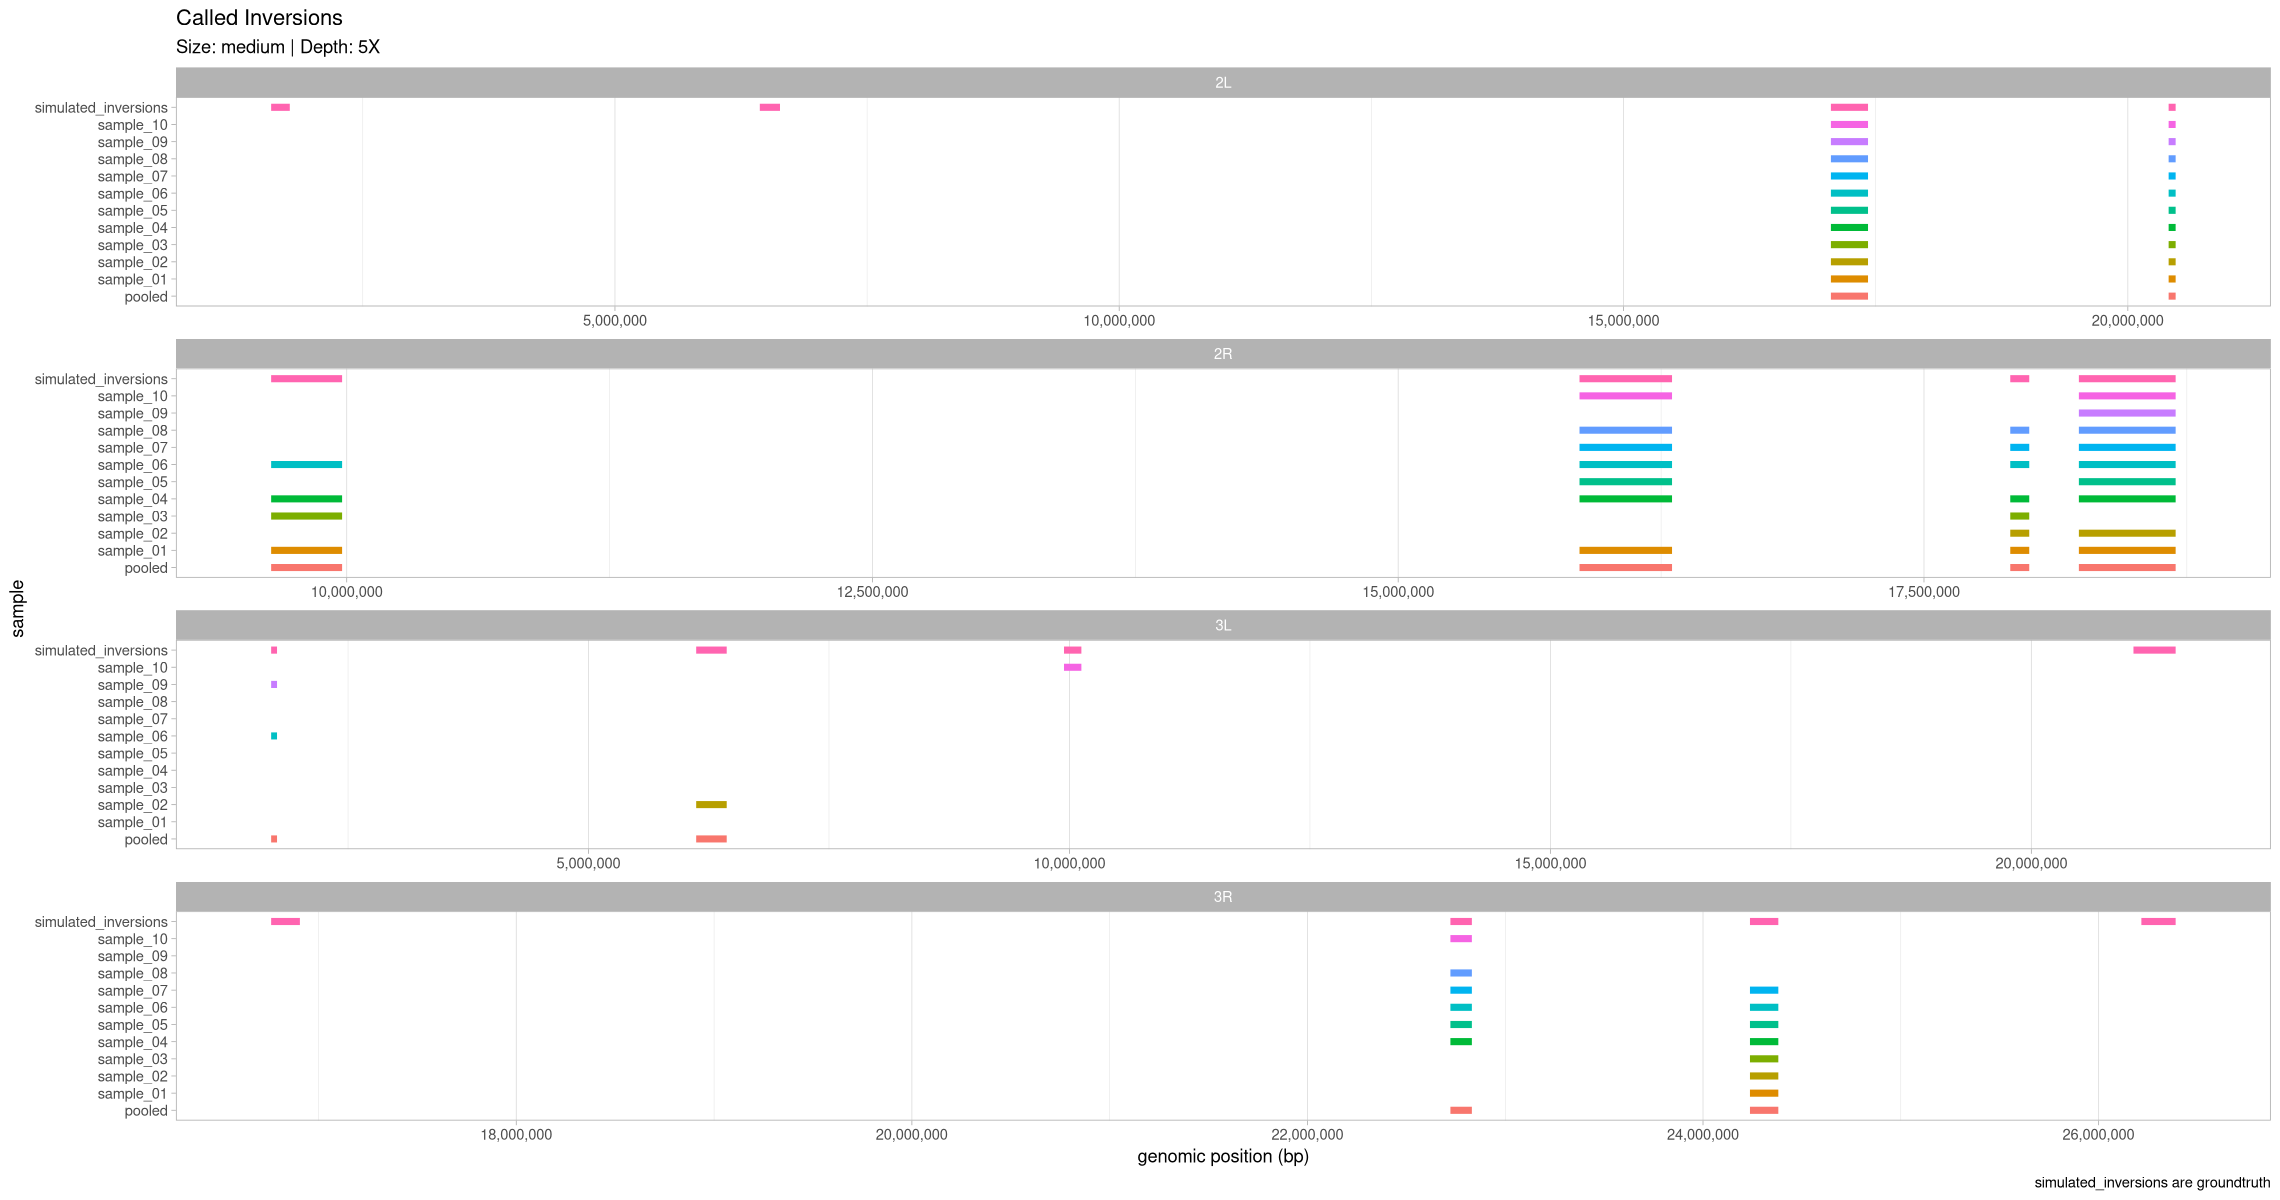

In [20]:
assessment_5X <- summarize_performance(5, performance, .size)

## 10X Depth

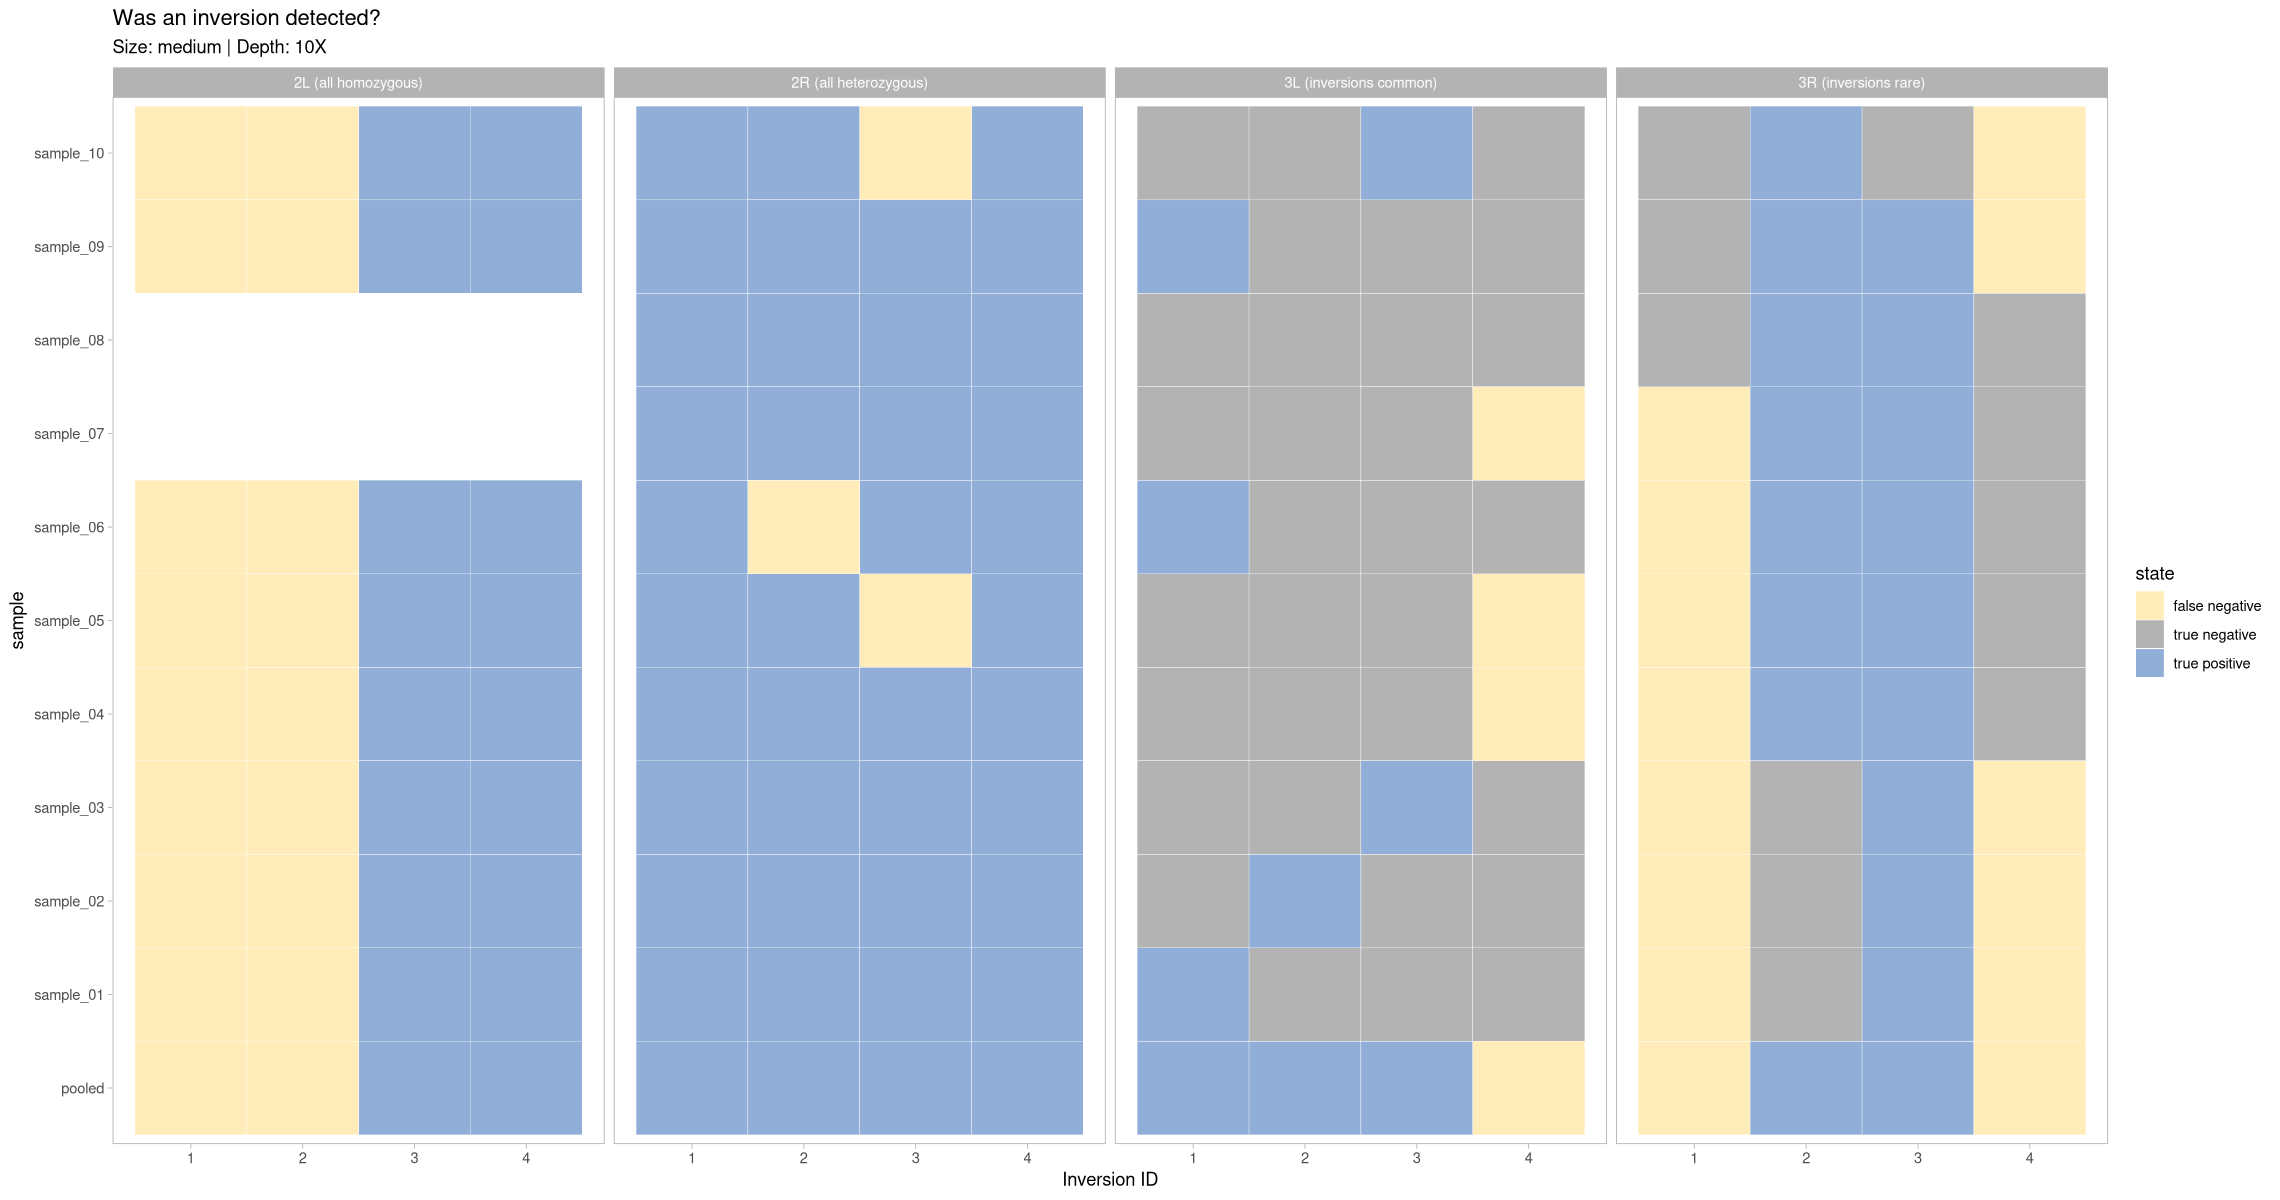

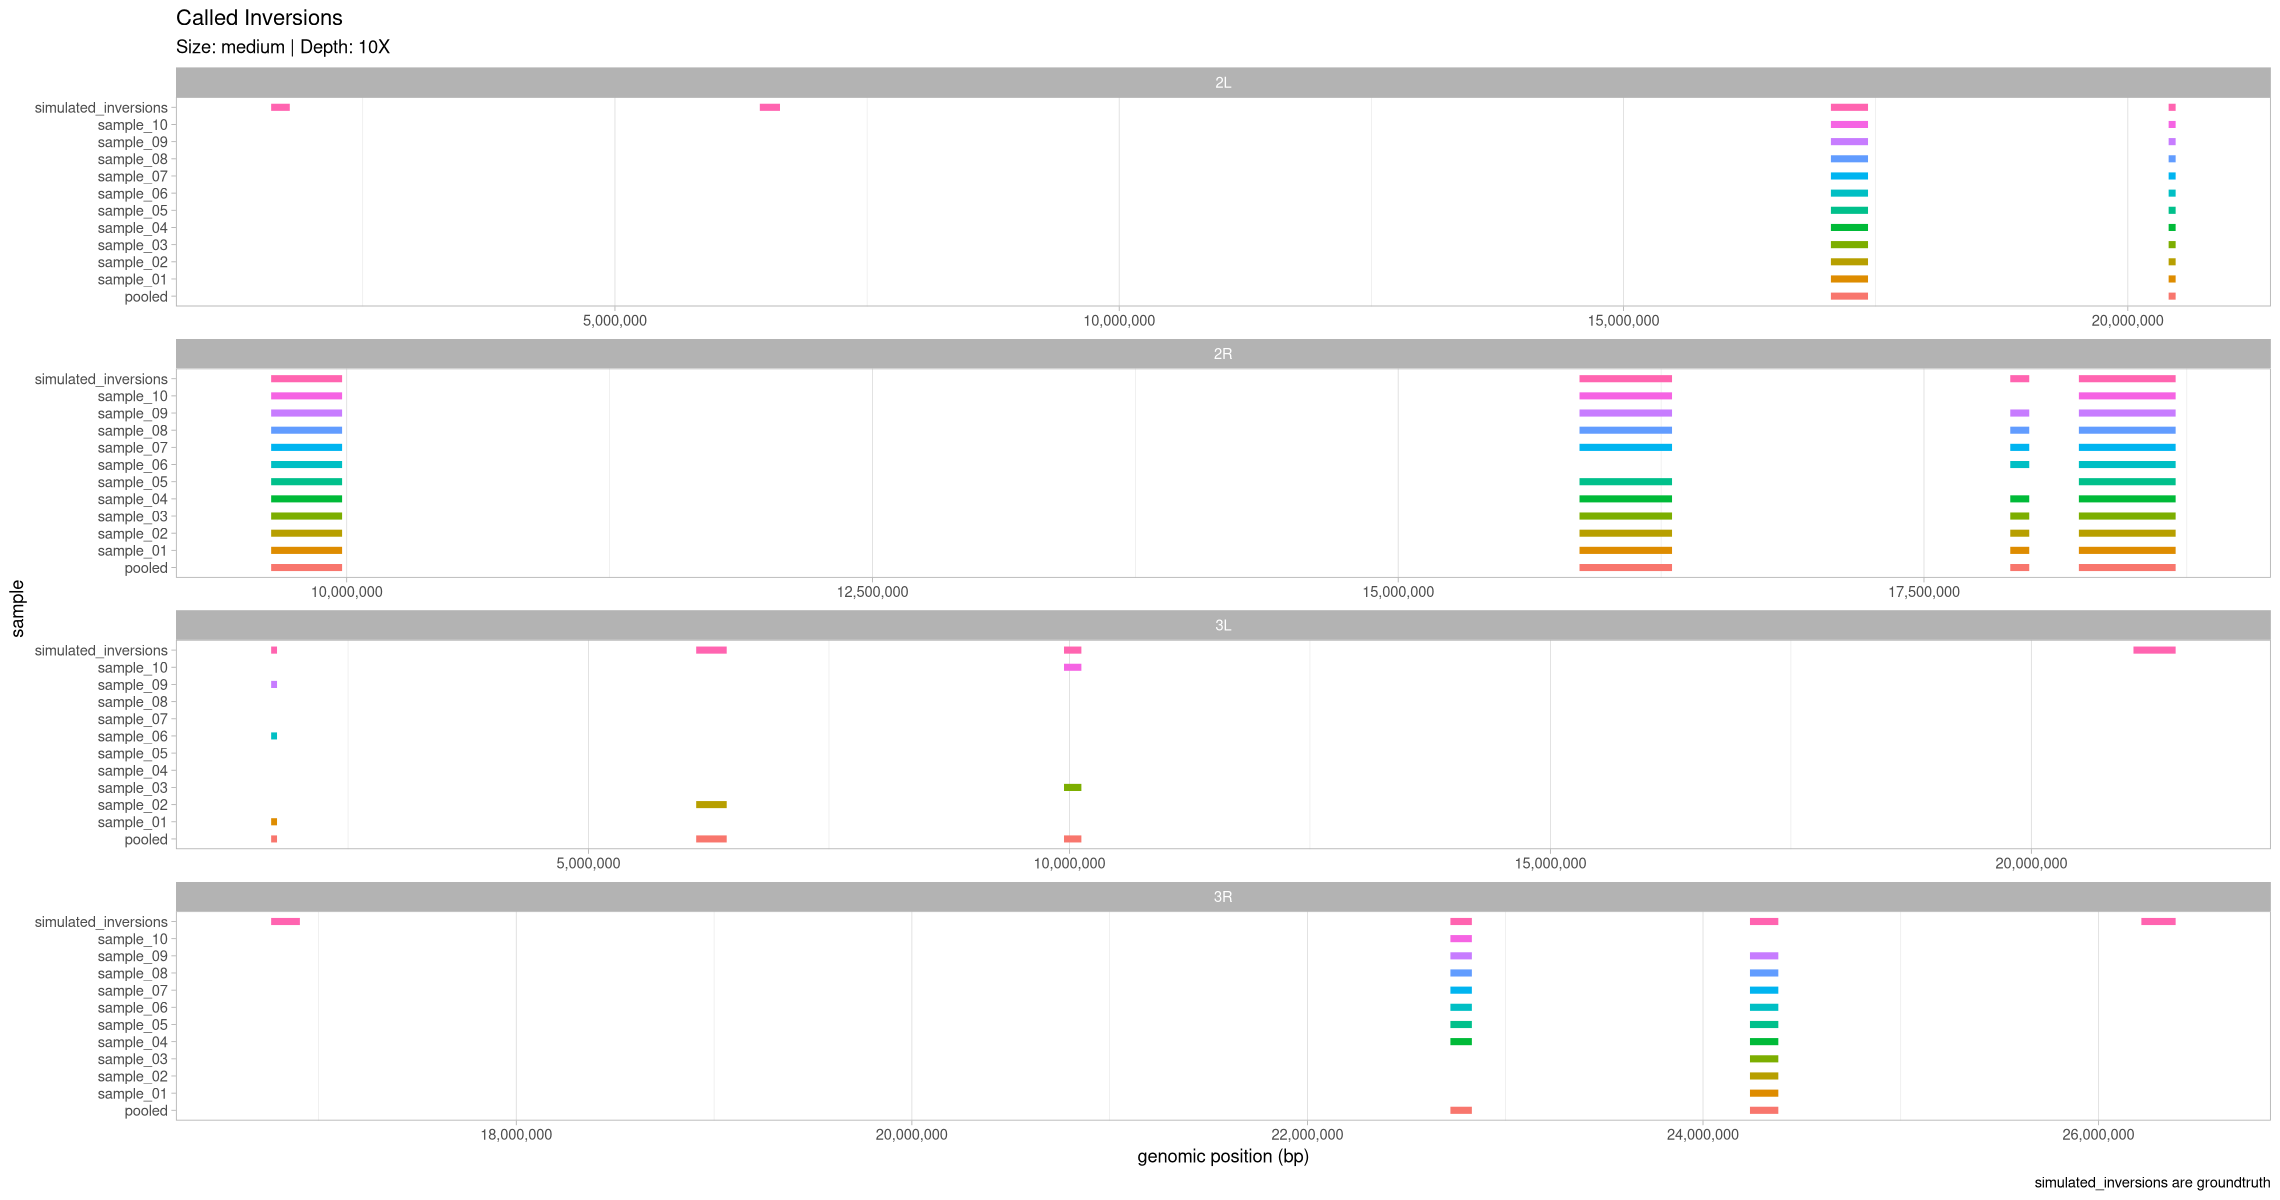

In [21]:
assessment_10X <- summarize_performance(10, performance, .size)

## 20X Depth

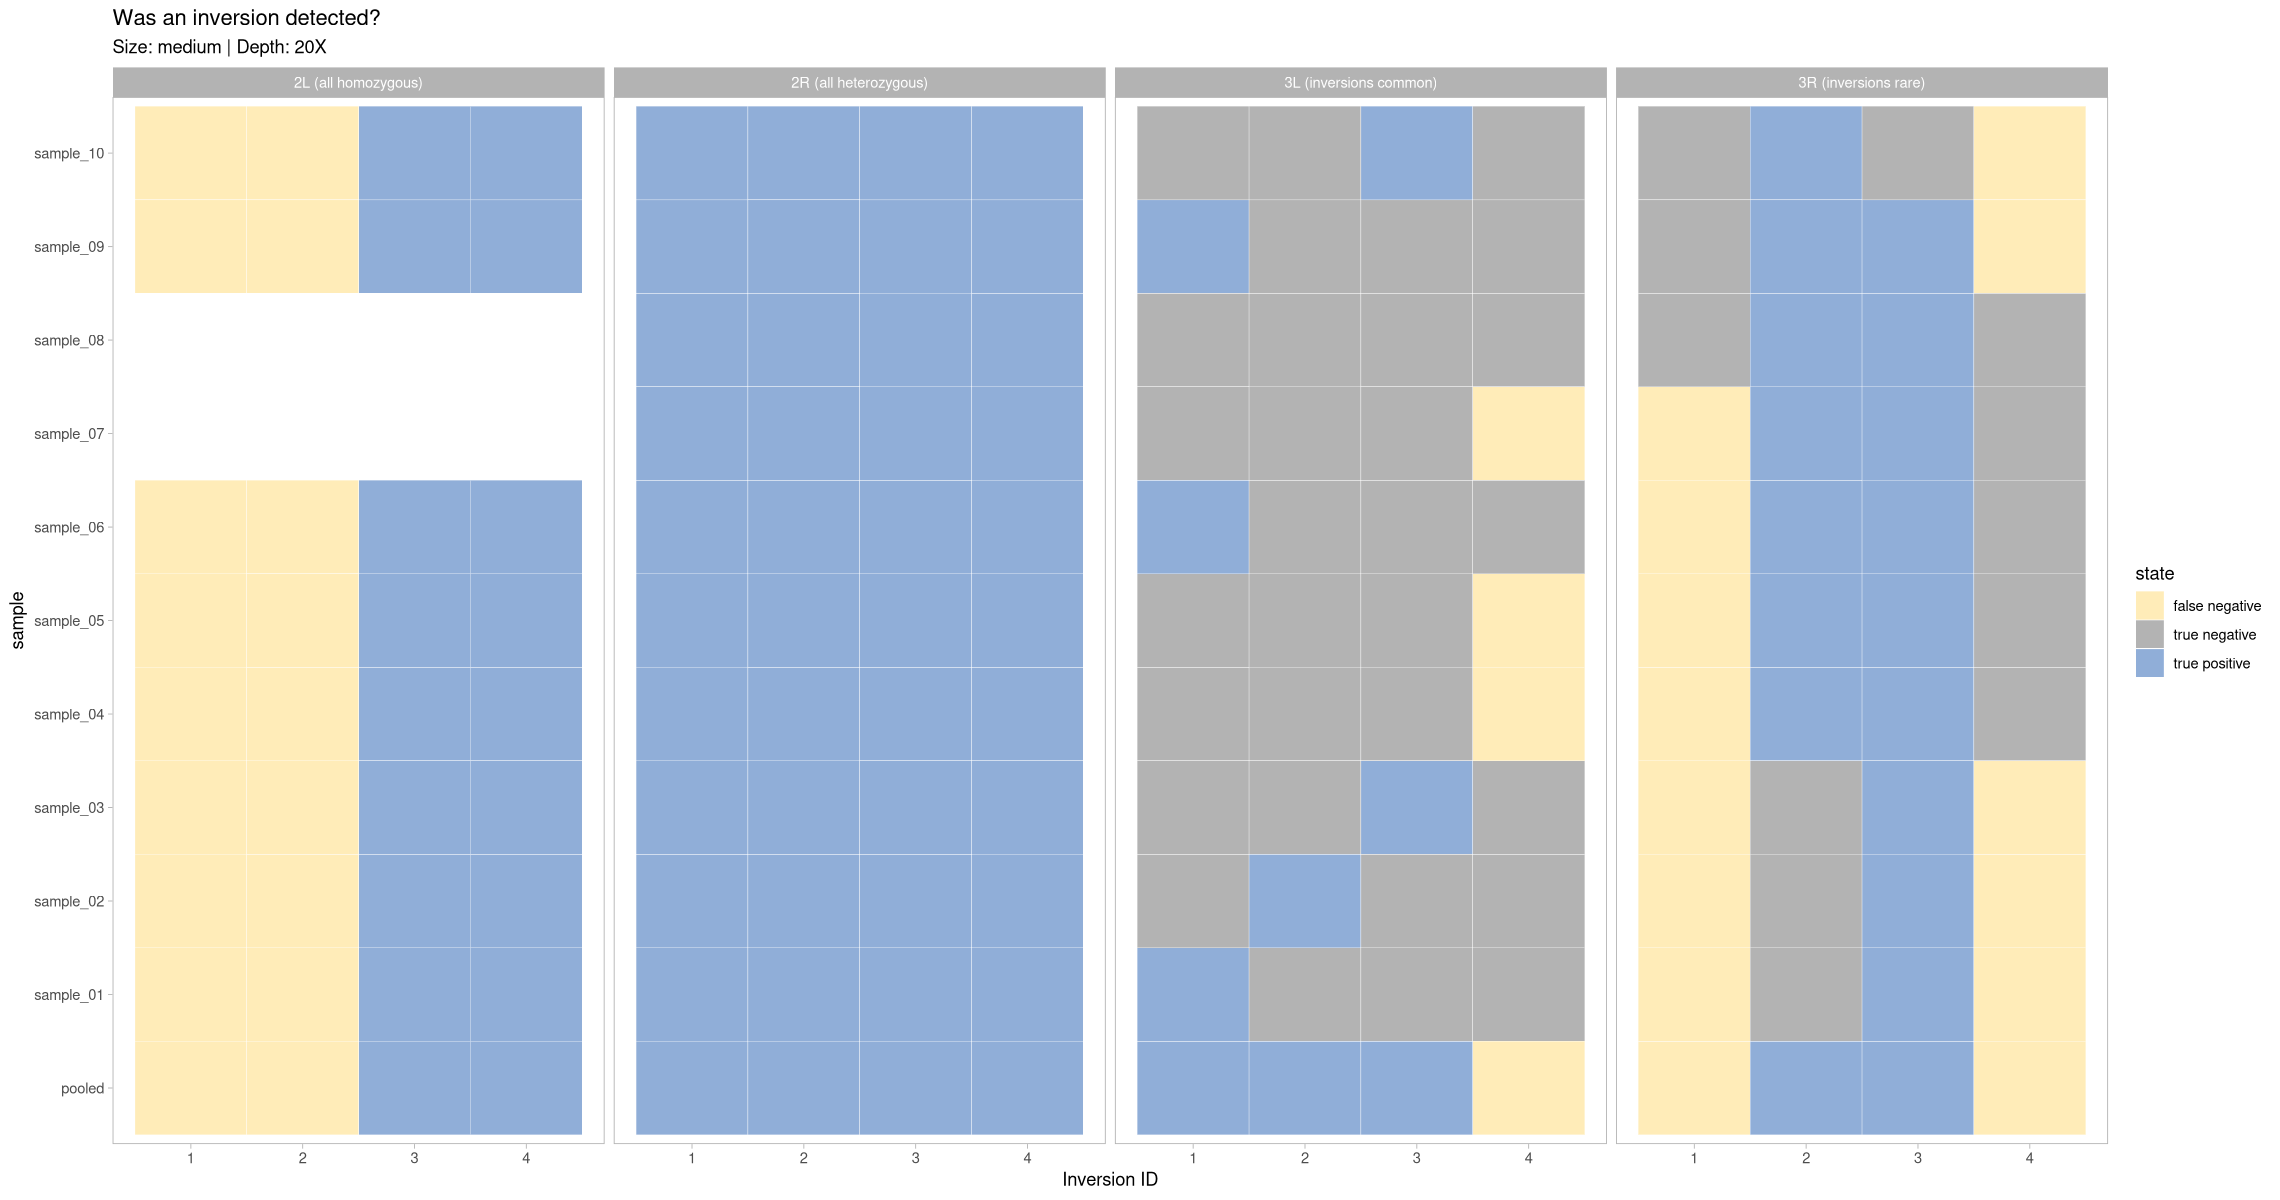

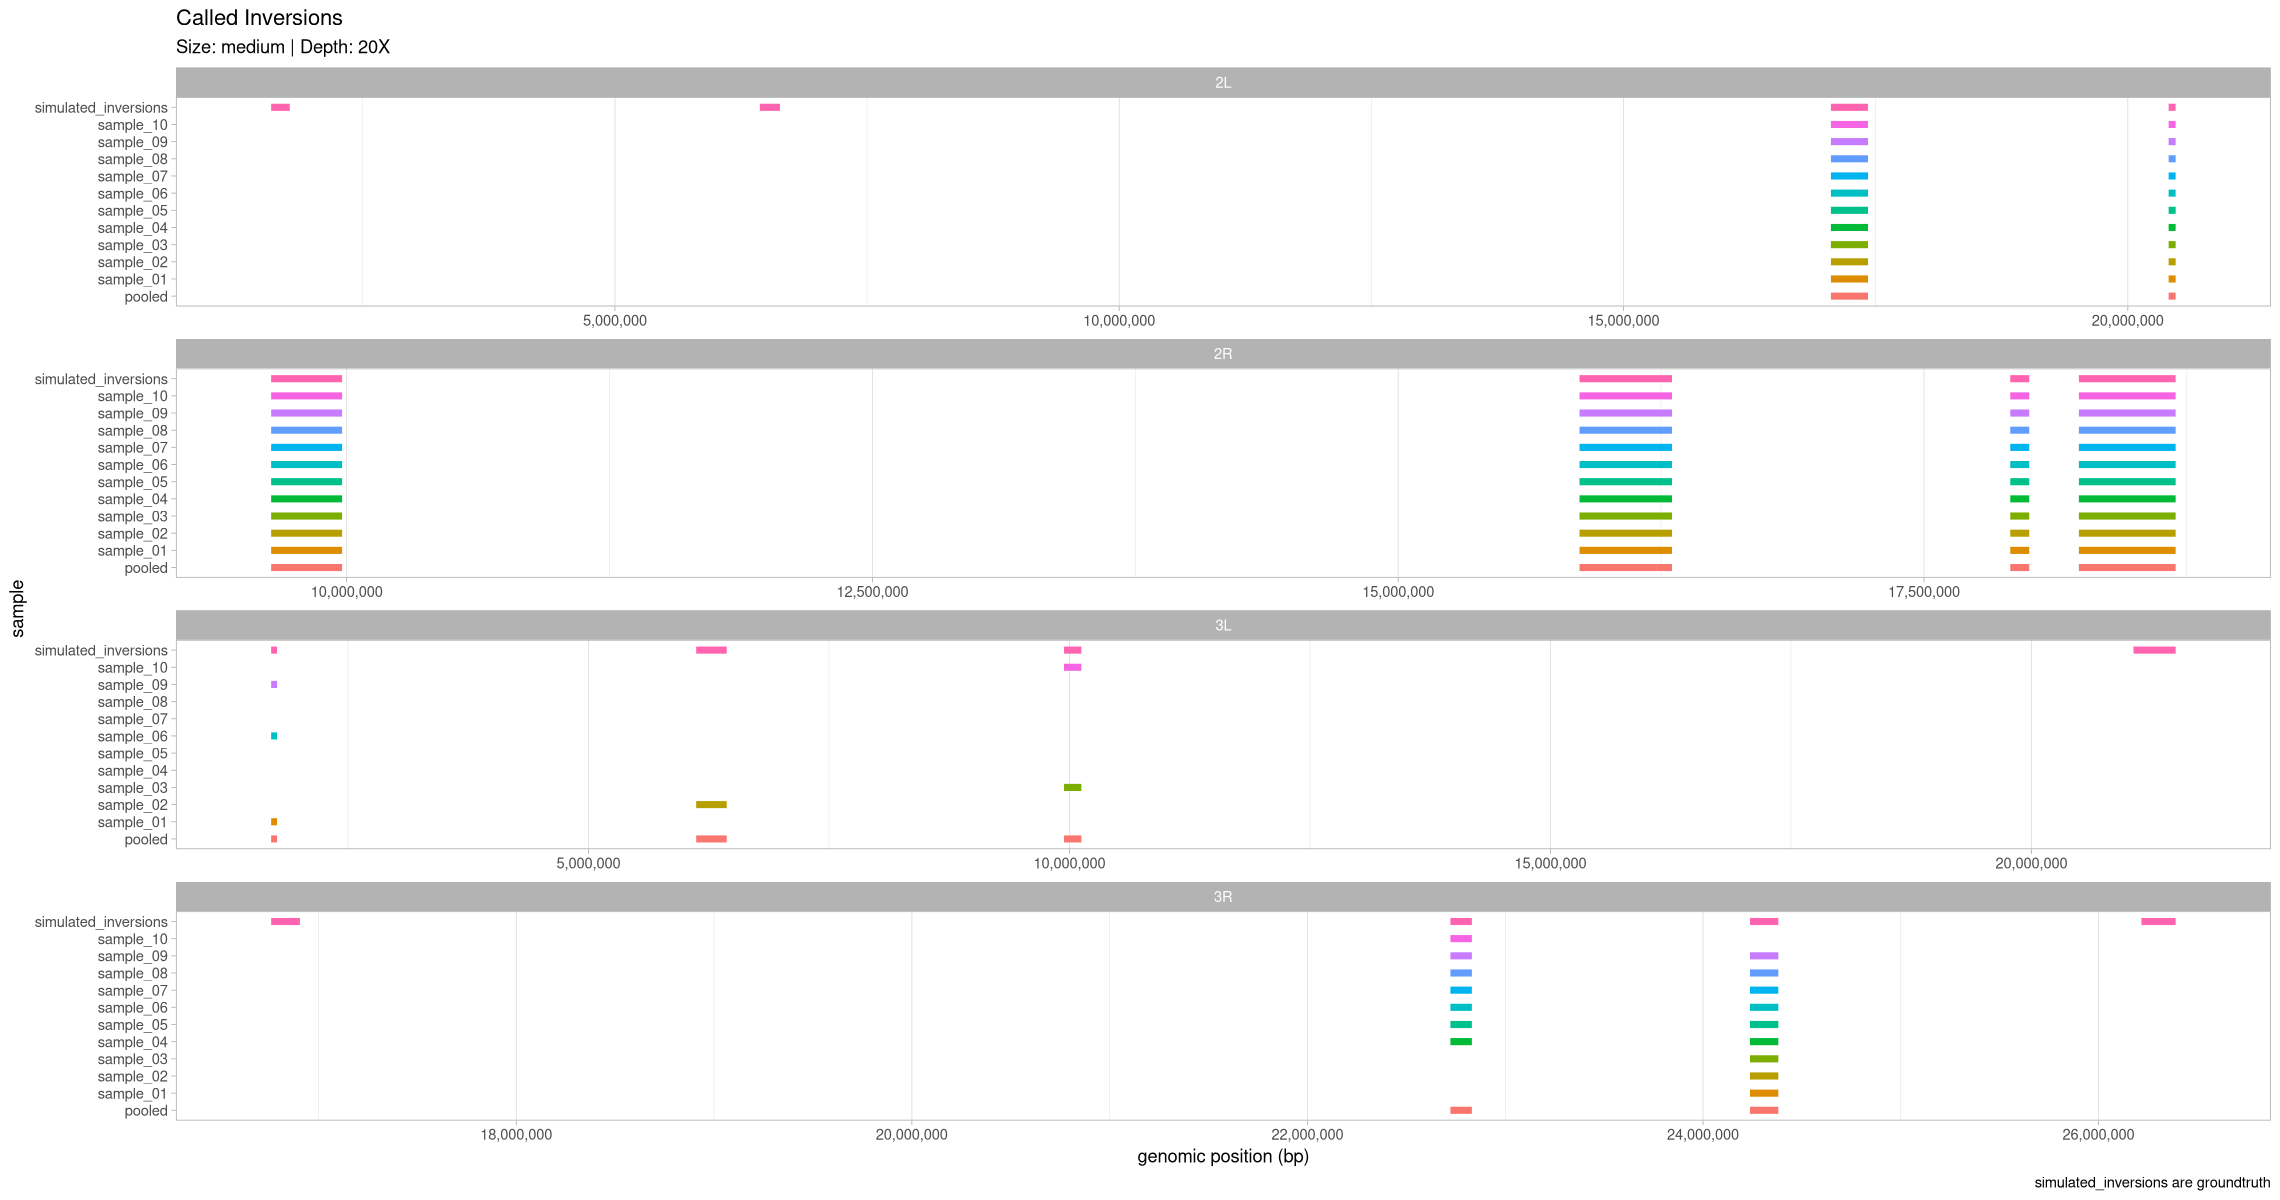

In [22]:
assessment_20X <- summarize_performance(20, performance, .size)

Write the results to a file

In [23]:
.x <- list(assessment_05X, assessment_2X, assessment_5X, assessment_10X, assessment_20X)
depths  <- c(0.5, 2, 5, 10, 20)
aggregate_df <- assessment_05X[0,]
aggregate_df$depth <- character()
for(i in 1:5){
    .tbl <- .x[i][[1]]
    .tbl$depth <- depths[i]
    aggregate_df <- rbind(aggregate_df, .tbl)
}
# sort it to make it visually sensible
aggregate_df <- arrange(aggregate_df, contig,inversion,depth, sample)
# restore contig names
aggregate_df$contig <- gsub("\\s*\\([^\\)]+\\)", "", aggregate_df$contig)
head(aggregate_df)
write.csv(aggregate_df, file = paste0(.size, ".assessment"), quote = F, row.names = F)

,contig,inversion,position_start,position_end,sample,size,simulated,zygosity,state,depth
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>
1,2L,1,1591146,1776073,pooled,medium,TRUE,hom,false negative,0.5
2,2L,1,1591146,1776073,sample_01,medium,TRUE,hom,false negative,0.5
3,2L,1,1591146,1776073,sample_02,medium,TRUE,hom,false negative,0.5
4,2L,1,1591146,1776073,sample_03,medium,TRUE,hom,false negative,0.5
5,2L,1,1591146,1776073,sample_04,medium,TRUE,hom,false negative,0.5
6,2L,1,1591146,1776073,sample_05,medium,TRUE,hom,false negative,0.5
